# Adversary Class

## Purpose

As I refine the existing design, I hope to become more aware of renewed purpose and utility of the adversary class. I will list them below in the order in which they arrive:

- To test spoofing detection algorithms on scenarios with and without spoofing
- To demonstrate the bounds on the spoofer's capacity
- To realize the influence of spoofing on fused data, with varying sensor noise levels


## Definitions and Assumptions:

- `spoofing_duration` $>>$ `abs(target_y)`

    - `spoofing_duration` is the period during which the UAV is made to deviate from its `true_trajectory` describing originally intended flight path. 
        - Initially, I was under the assumption that `spoofing_duration` is the entire duration of spoofing. However, following a preliminary discussion with an expert, I've come to realize that once the adversary has spoofed the GPS of the UAV, it must continue to *'fictionalize'* the UAV's false perception of normalcy. That is, the spoofer must continue to spoof the GPS location until the spoofer's objective has been satisfied. 
    - `target_y` is the target North/South coordinate of the spoofer's `malicious_trajectory` describing the flight course planned by the adversary. 
    
-  `tracking_error` or `epsilon` describes the tolerance and is given by $\pm 1$ about the y-axis of the `true_trajectory`.
- The UAV's intended ground velocity is assumed to be constant in the east direction. 
- The spoofer has full knowledge of the true_trajectory. 
- Course correction initiates on the step next to detection outside green zone.
- UAV relies completely on GPS w/o any fusion. 
- Spoofing is applied to only one direction

Targets for the spoofer:
- Don't cross the max velocity
- Don't roll out of the green zone prematurely. 

## Future targets

- Instead of generating the true trajectory synthetically, add spoofing signals to a given GPS trajectory. 
- Don't assume constant velocity. 
- Introduce max velocity as an input to the adversary class so that the adversary must decide on strategies with restrictions on maximum velocity achievable by the UAV. 

In [136]:
import copy
import numpy as np
import matplotlib.pyplot as plt

In [174]:
class adversary:
    
    def __init__(self, uav_velocity_x, tracking_error, spoofing_duration, target_y, start_x):

        
        # for reproducability
        np.random.seed(10)
        
        self.x_range            = 10000 # intended course: 0 unit to 9999 unit east
        self.v                  = uav_velocity_x
        self.epsilon            = tracking_error # true_trajectory[i][1] +- epsilon = green zone
        self.tao                = spoofing_duration
        self.target_y           = target_y # where spoofer wants to take the UAV to on North/South axis
        self.spoof_rate         = self.tao // np.abs(self.target_y) # time per unit North/South spoof
        self.y_jump             = -1 # size and direction of pose correction
        self.start_x            = start_x # starting x_index for spoofing
        self.end_x              = start_x + (self.tao * self.v) # finishing x_index for spoofing
        
        # pre-flight planned course, known to the UAV
        self.true_trajectory    = [[self.v*t,np.random.uniform(-.1,.1)] for t in range(self.x_range)] 
        
        # course planned by the spoofer, unknown to the UAV
        self.malicious_trajectory = [[self.v*t,np.random.normal(0,.1)] for t in range(self.x_range)]
        
        # UAV's belief about its location, known to the UAV
        # true_trajectory is given to the UAV in the form of waypoints. The GPS acts as a guide to track said 
        # waypoints, and as a result the trajectory is supposed to be noisy
        self.gps_spoofed_path   = copy.deepcopy(self.true_trajectory)
        
         # input validation
        if self.tao > self.x_range-100: # 100 steps to resolve overlap conflicts
            raise ValueError("Spoofing cannot be executed for longer than the flight duration")
        if self.target_y == 0: # avoid dividing by zero
            raise ValueError("Target location cannot be zero")
        if self.spoof_rate <= self.y_jump:
            raise ValueError("Spoofing rate must be greater than jump sizes")

        
    # creates malicious_trajectory with parameters: spoofing_duration, target_y, start_x, y_jump rate
    def create_mal_traj(self):
        window  = self.spoof_rate 
        #  the attack pattern is cyclic, window determines the duration of each cycle
        i = self.start_x
        y_current = self.gps_spoofed_path[i][1] # set the current y position of the UAV to the GPS
        while i < self.x_range:
            if np.abs(y_current) < np.abs(self.target_y): # if target_y is yet to be reached
                for j in range(window):
                    self.malicious_trajectory[i+j][1] += y_current 
                y_current += self.y_jump
            else: # target deviation has been acheieved, now maintain the deviation
                for j in range(window):
                    self.malicious_trajectory[i+j][1] += y_current
            i  += window
            
    def create_spoofed_gps(self, climb_rate):
    
        # for now assume that jumps are one unit at a time, but wait time is tunable
        window         = self.spoof_rate 
        
        # UAV's belief about it's position is fully informed by the GPS alone
        belief_y       = self.gps_spoofed_path[self.start_x][1] 
        spark          = 0 # number of times GPS triggered course corrections
        
        # greedy implementation
        ## climb up until on the edge of the green zone. 
        ## start climbing down at the beginning of a window
        ## assumes that window >> gps_jump
        
        for i in range(self.start_x+1,self.end_x):
            # edge is the y value of the boundary of green zone
            # climb up to the edge but don't cross green zone 
            edge     = self.true_trajectory[i][1] + self.epsilon
            if spark < abs(self.target_y):  # number of sparks is smaller than needed to reach target_y
                if (i % window) < window-1: # between 0,1, . . , n-2 step in the window
                    if belief_y < edge: # UAV beliefs that it's within the green zone
                        self.gps_spoofed_path[i][1] += climb_rate + belief_y # climb to the edge
                        belief_y = self.gps_spoofed_path[i][1] # update belief

                    # remain on the edge until the end of the window
                    elif belief_y == edge:
                        self.gps_spoofed_path[i][1] += belief_y

                    else: # climb back in if outside the green zone
                        self.gps_spoofed_path[i][1] += belief_y - climb_rate     

                else:
                    # cross green zone 
                    self.gps_spoofed_path[i][1] += climb_rate + belief_y
                    spark += 1
                    
            else:
                while belief_y > 0: # once drift has fully been added, climb down to intended course
                    self.gps_spoofed_path[i][1] = belief_y
                    belief_y -= climb_rate      
                self.gps_spoofed_path[i][1] = belief_y # maintain false belief for the remainder of the trip
                    
                
            
    def add_wind_drift(self): 
        return  
    
    # return trajectories
    def return_mal_traj(self):
        return np.array(copy.deepcopy(self.malicious_trajectory))
    def return_tru_traj(self):
        return np.array(copy.deepcopy(self.true_trajectory))
    def return_spoofed_gps(self):
        return np.array(copy.deepcopy(self.gps_spoofed_path))
    
    # visualize trajectories
    def visualize_true(self, start_x = 0, end_x = 1000):
        i = start_x
        j = end_x
        Y = np.array(self.true_trajectory)
        plt.figure(figsize=(10,5))
        plt.plot(Y[:, 0][i:j], Y[:, 1][i:j], color='blue', label = 'True (intended) Course')
        plt.xlabel('X Position (m)', fontsize=10)
        plt.ylabel('Y Position (m)', fontsize=10)
        
    def visualize_spoofed_gps(self, start_x = 0, end_x = 1000):
        i = start_x
        j = end_x
        Z = np.array(self.gps_spoofed_path)
        plt.figure(figsize=(10,5))
        plt.plot(Z[:, 0][i:j], Z[:, 1][i:j], color='orange', label = 'GPS trajectory')
        plt.xlabel('X Position (m)', fontsize=10)
        plt.ylabel('Y Position (m)', fontsize=10)
        plt.legend()
    

    def visualize_malicious(self, start_x = 0, end_x = 1000):
        i = start_x
        j = end_x
        X = np.array(self.malicious_trajectory)
        plt.figure(figsize=(10,5))
        plt.plot(X[:, 0][i:j], X[:, 1][i:j], color='red', label = 'Malicious trajectory')
        plt.xlabel('X Position (m)', fontsize=10)
        plt.ylabel('Y Position (m)', fontsize=10)
        plt.legend()
        
    def visualize_all(self, start_x = 0, end_x = 1000):
        i = start_x
        j = end_x
        X = np.array(self.malicious_trajectory)
        Y = np.array(self.true_trajectory)
        Z = np.array(self.gps_spoofed_path)
        plt.figure(figsize=(10,5))
        plt.plot(X[:, 0][i:j], X[:, 1][i:j], color='red', label = 'Malicious trajectory')
        plt.plot(Y[:, 0][i:j], Y[:, 1][i:j], color='blue', label = 'True (intended) Course')
        plt.plot(Z[:, 0][i:j], Z[:, 1][i:j], color='orange', label = 'GPS trajectory')
        plt.xlabel('X Position (m)', fontsize=10)
        plt.ylabel('Y Position (m)', fontsize=10)
        plt.fill_between(Y[:, 0][:j], Y[:, 1][:j]-1, Y[:, 1][:j]+1, color='green', alpha=0.15)
        plt.legend()


In [175]:
simple_adversary = adversary(1,1,100, -10,100)
simple_adversary.create_mal_traj()
simple_adversary.create_spoofed_gps(1)

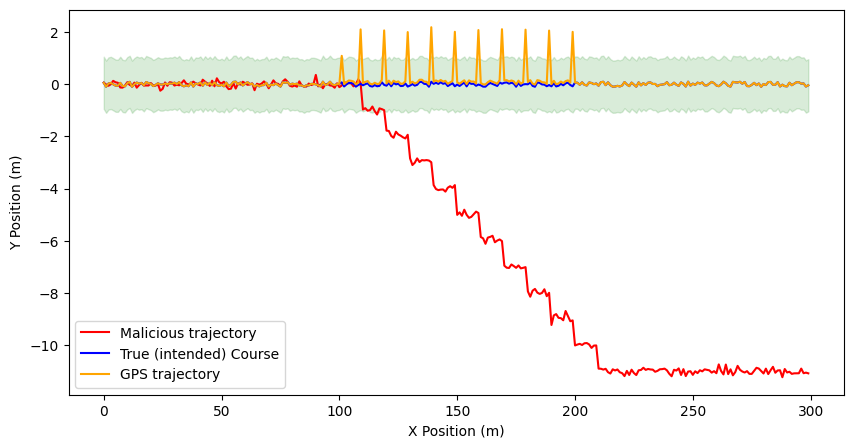

In [176]:
simple_adversary.visualize_all(0,300)

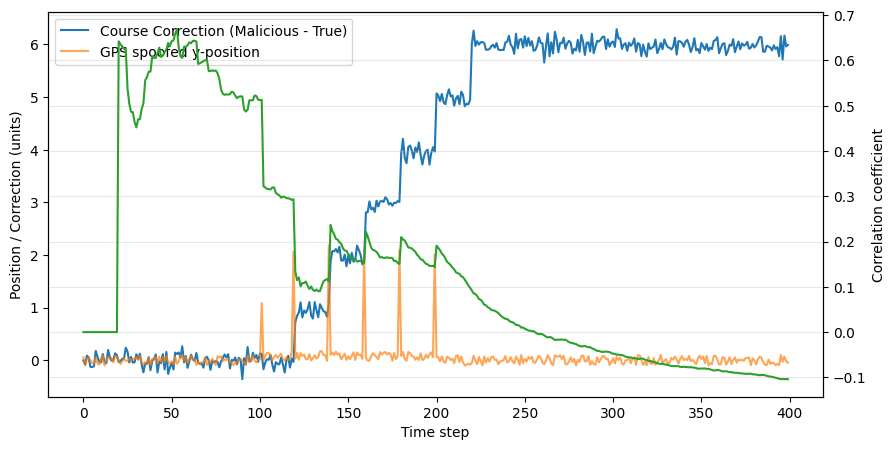

In [178]:
simple_adversary = adversary(1,1,100, -5, 100)
simple_adversary.create_mal_traj()
simple_adversary.create_spoofed_gps(1)
X = simple_adversary.return_mal_traj()
Y = simple_adversary.return_tru_traj()
Z = simple_adversary.return_spoofed_gps()

course_correction = Y[:,1] - X[:,1]
gps_y = Z[:,1]

rolling_corr = np.zeros(len(course_correction))
for i in range(window, len(course_correction)):
    rolling_corr[i] = np.corrcoef(course_correction[:i], gps_y[:i])[0,1]

fig, ax1 = plt.subplots(figsize=(10,5))

# plot the two series
ax1.plot(course_correction[:400], label='Course Correction (Malicious - True)', color='tab:blue')
ax1.plot(gps_y[:400], label='GPS spoofed y-position', color='tab:orange', alpha=0.7)
ax1.set_xlabel('Time step')
ax1.set_ylabel('Position / Correction (units)')
ax1.legend(loc='upper left')

# twin axis for rolling correlation
ax2 = ax1.twinx()
ax2.plot(rolling_corr[:400], color='tab:green', label='Correlation coefficient')
ax2.set_ylabel('Correlation coefficient')

plt.grid(True, alpha=0.3)
plt.show()

In [179]:
arr = [2,3,4,5]
arr[:2]

[2, 3]